# Multi-view context lighting probe

For one fixed object, the same complete $6\times500$ camera--illumination grid is processed in two paired RayDer conditions: every image independently, or all six camera images jointly. The experiment asks whether **multi-view context** merely moves the representation or makes illumination more consistently factorizable across views.

The comparison deliberately keeps the parallel axes established by the preceding notebooks:

| representation | independent | six-view context |
|---|---:|---:|
| RayDer pose-head-normalized token (1024D) | yes | yes |
| RayDer nuisance projection (256D) | yes | yes |
| frozen DINOv3 token (1024D) | one per-image reference | not applicable |

DINOv3 is an appearance-oriented generic visual reference, not a pure appearance oracle. It has no native multi-view-context condition and is therefore evaluated once rather than duplicated under a misleading label.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/rayder-matplotlib")

import math
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial.transform import Rotation
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "rayder").is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from notebooks.common import (
    AXIS_LABELS, DINO_ID, annotated_heatmap, load_dino, load_rayder,
    partial_spearman, rayder_features, sample_mixtures, select_axis_lights,
    spearman, spherical_w1, standardize, two_factor_energy, variance_weighted_r2,
)
from rayder.open_illumination import OpenIlluminationOLAT


/mnt/warm/dev/rayder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experimental design

Mixture $i$ is $w_i\in\Delta^5$ over the six measured directions $\ell_k$ nearest $\{\pm x,\pm y,\pm z\}$. Four symmetric Dirichlet families span concentrated through diffuse illumination. Identical rendered tensors and identical held-out-mixture splits are reused for all feature conditions.

For view $v$ and mixture $i$, write the independent and contextual RayDer features as $z^{r,ind}_{vi}$ and $z^{r,ctx}_{vi}$. Their paired difference

$$\Delta z^r_{vi}=z^{r,ctx}_{vi}-z^{r,ind}_{vi}$$

isolates the effect of a joint six-view model call. It does not by itself establish better lighting encoding; the later factorization, geometry, and held-out probes test that separately. Temporal ranks are fixed to camera identity in the main experiment.


/home/user/.pyenv/versions/3.13.7/lib/python3.13/contextlib.py:141: UserWarning: CUDA reports that you have 2 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(torch.cuda.device_count())`.
  return next(self.gen)


+x: light  82, direction=[0.9949327707290649, 0.012538393028080463, -0.09975770115852356]
-x: light  77, direction=[-0.9934996366500854, 0.055403318256139755, 0.09944342076778412]
+y: light 139, direction=[0.32102105021476746, 0.8998042941093445, 0.2954619228839874]
-y: light   0, direction=[0.002798927715048194, -0.987995445728302, 0.15445780754089355]
+z: light  62, direction=[-0.11902597546577454, 0.013896279968321323, 0.9927939176559448]
-z: light  86, direction=[0.13224151730537415, 0.05854164436459541, -0.9894872903823853]


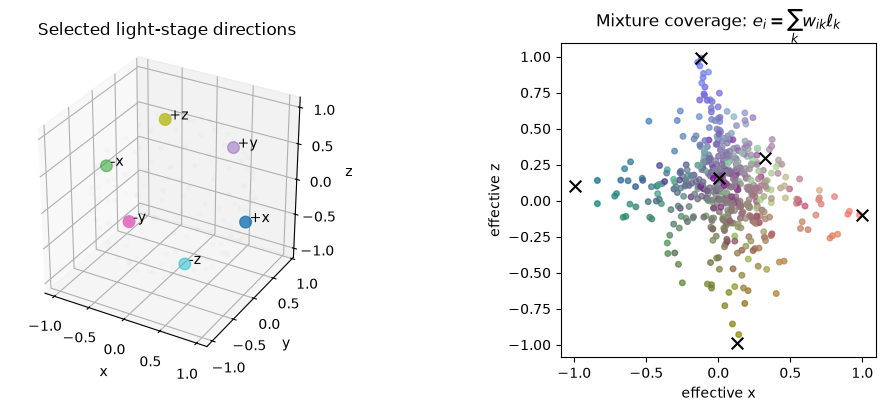

In [2]:
DATA_ROOT = REPO_ROOT / "notebooks/data/openillumination-mini"
OBJECT_ID, CAMERAS, RESOLUTION = 5, ("A1", "A2", "A3", "A4", "A5", "A6"), 256
NUM_MIXTURES, SEED, EXPOSURE_EV = 500, 20260902, 3.0
RENDER_BATCH_SIZE, INDEPENDENT_BATCH_SIZE, CONTEXT_BATCH_SIZE = 2, 12, 2
MASK, IMAGE_DISTANCE_MASK, SUBTRACT_BACKGROUND = None, "object", False
RIDGE_ALPHA, ORDER_SAMPLES_PER_FAMILY, NUM_ORDER_PERMUTATIONS = 10.0, 6, 4

dataset = OpenIlluminationOLAT(DATA_ROOT, OBJECT_ID, download_missing=False)
light_directions, light_indices, selected_directions = select_axis_lights(dataset)
mixture_weights, mixture_family = sample_mixtures(NUM_MIXTURES, SEED)
families = mixture_family.unique(sorted=True)
view_indices = torch.arange(len(CAMERAS))
fixed_temporal_ranks = view_indices.clone()

generator = torch.Generator().manual_seed(SEED + 1)
train_parts, test_parts = [], []
for alpha in families:
    indices = torch.where(mixture_family == alpha)[0]
    indices = indices[torch.randperm(len(indices), generator=generator)]
    boundary = int(0.8 * len(indices))
    train_parts.append(indices[:boundary])
    test_parts.append(indices[boundary:])
train_indices, test_indices = torch.cat(train_parts), torch.cat(test_parts)

effective_lights = mixture_weights @ selected_directions
direction_colors = ((effective_lights + 1) / 2).clamp(0, 1)
for label, index, direction in zip(AXIS_LABELS, light_indices, selected_directions):
    print(f"{label:>2}: light {index.item():3d}, direction={direction.tolist()}")

fig = plt.figure(figsize=(11, 4), constrained_layout=True)
ax = fig.add_subplot(121, projection="3d")
ax.scatter(*light_directions.T, s=8, alpha=0.15, color="0.4")
ax.scatter(*selected_directions.T, s=70, c=range(6), cmap="tab10")
for label, direction in zip(AXIS_LABELS, selected_directions): ax.text(*direction, f" {label}")
ax.set(title="Selected light-stage directions", xlabel="x", ylabel="y", zlabel="z")
ax.set_box_aspect((1, 1, 1))
ax = fig.add_subplot(122)
ax.scatter(*effective_lights[:, [0, 2]].T, c=direction_colors, s=16, alpha=0.75)
ax.scatter(*selected_directions[:, [0, 2]].T, c="black", marker="x", s=70)
ax.set(title=r"Mixture coverage: $e_i=\sum_k w_{ik}\ell_k$", xlabel="effective x", ylabel="effective z", aspect="equal")
plt.show()


## Matched inputs across cameras

Three sampled mixtures near the 90th, 50th, and 10th percentiles of $\|w_i-\mathbf{1}/6\|_2$ show concentrated through diffuse illumination. Rows are real experimental conditions rather than privileged one-hot anchors; columns change only the camera.


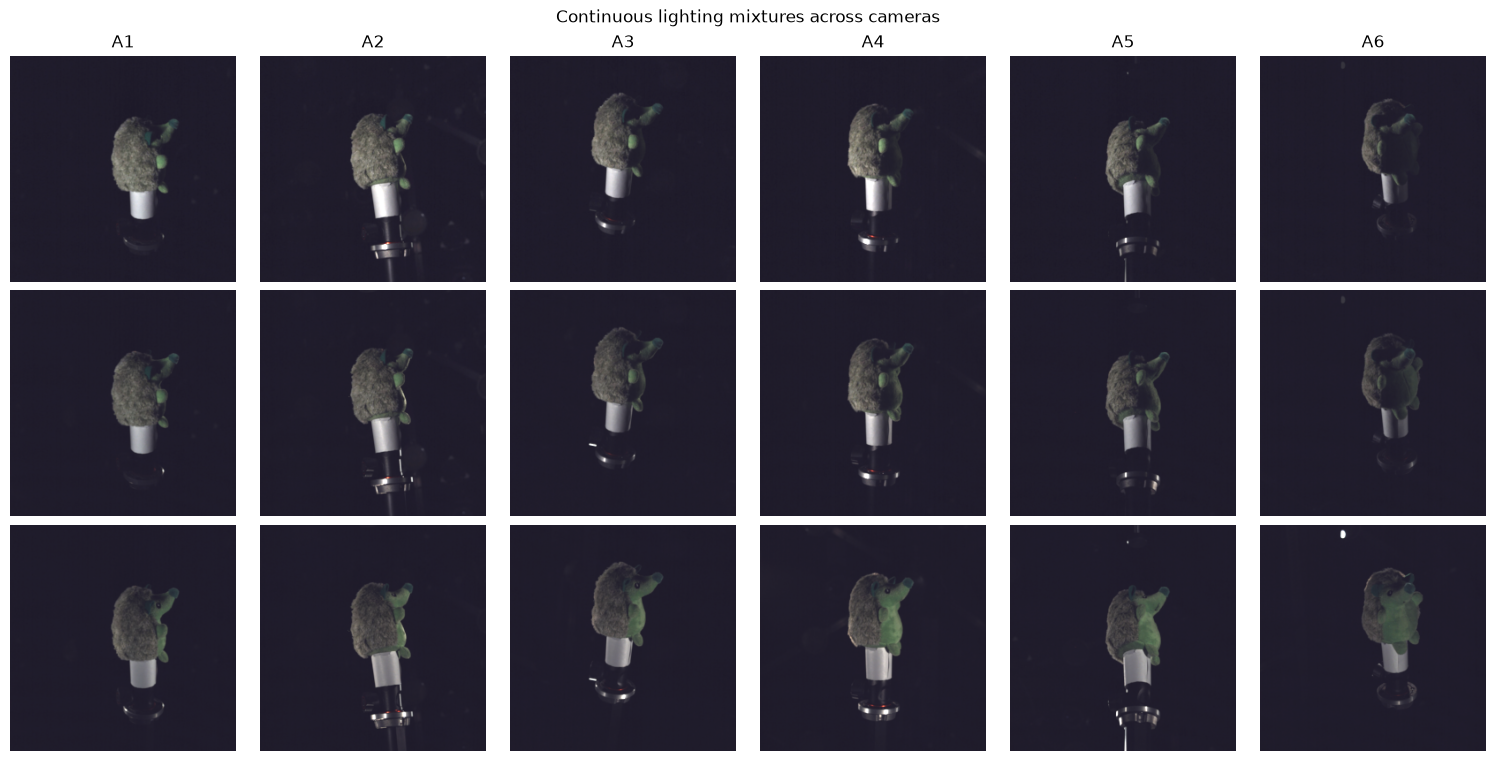

preview range=[0.0951, 1.0000], clipped channels=0.0516%


In [3]:
radius = torch.linalg.vector_norm(mixture_weights - 1 / 6, dim=1)
quantiles = torch.tensor([0.9, 0.5, 0.1])
preview_indices = torch.stack([(radius - radius.quantile(q)).abs().argmin() for q in quantiles])
preview = dataset.render_weight_batch(
    mixture_weights[preview_indices].numpy(), cameras=CAMERAS, light_indices=light_indices.numpy(),
    size=RESOLUTION, center_crop=True, exposure_ev=EXPOSURE_EV, mask=MASK,
    subtract_background=SUBTRACT_BACKGROUND,
)
fig, axes = plt.subplots(3, len(CAMERAS), figsize=(15, 7.5), constrained_layout=True)
for row, (axes_row, images, index, quantile) in enumerate(zip(axes, preview, preview_indices, quantiles)):
    for ax, image, camera in zip(axes_row, images, CAMERAS):
        ax.imshow(image); ax.set_title(camera if row == 0 else ""); ax.axis("off")
    axes_row[0].set_ylabel(f"q={quantile:.1f}\nmax w={mixture_weights[index].max():.2f}")
fig.suptitle("Continuous lighting mixtures across cameras")
plt.show()
print(f"preview range=[{preview.min():.4f}, {preview.max():.4f}], clipped channels={100 * (preview >= 1).mean():.4f}%")


## Paired feature extraction

Every rendered batch is reused immediately. The independent path flattens `(mixture, view)` into one-view inputs; the contextual path preserves all six views and assigns temporal rank by camera identity. Both are restored to `(view, mixture, feature)`.

RayDer yields the pose-head-normalized backbone token, nuisance projection, rotation, translation, and focal length. DINOv3 receives each same crop independently and contributes its pooled token once.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp = dict(device_type=device.type, dtype=torch.bfloat16, enabled=device.type == "cuda")
rayder_model = load_rayder(device)
dino_model, dino_mean, dino_std = load_dino(device, DINO_ID)
print(f"device={device}; RayDer token={rayder_model.width}D, nuisance={rayder_model.d_dynamic_state}D; DINO={dino_model.config.hidden_size}D")

def unpack(cameras, tokens, nuisance):
    return {
        "token": tokens.float().cpu(), "nuisance": nuisance.float().cpu(),
        "rotation": cameras.R.float().cpu(), "translation": cameras.t.float().cpu(),
        "focal": cameras.f.float().cpu(),
    }

@torch.no_grad()
def infer_independent(images):
    flat = torch.from_numpy(images).flatten(0, 1)
    parts = {name: [] for name in ("token", "nuisance", "rotation", "translation", "focal", "dino")}
    for start in range(0, len(flat), INDEPENDENT_BATCH_SIZE):
        image_batch = flat[start : start + INDEPENDENT_BATCH_SIZE].to(device)
        with torch.autocast(**amp):
            cameras, tokens, nuisance = rayder_features(rayder_model, image_batch[:, None].mul(2).sub(1))
            dino = dino_model(pixel_values=(image_batch.permute(0, 3, 1, 2) - dino_mean) / dino_std).pooler_output
        values = unpack(cameras, tokens, nuisance)
        for name in parts:
            parts[name].append(dino.float().cpu() if name == "dino" else values[name][:, 0])
    shape = (len(images), len(CAMERAS))
    return {name: torch.cat(values).reshape(*shape, *torch.cat(values).shape[1:]) for name, values in parts.items()}

@torch.no_grad()
def infer_context(images, order=view_indices, temporal_ranks=fixed_temporal_ranks):
    order, temporal_ranks = torch.as_tensor(order), torch.as_tensor(temporal_ranks)
    inverse = torch.argsort(order)
    ordered = torch.from_numpy(images)[:, order]
    parts = {name: [] for name in ("token", "nuisance", "rotation", "translation", "focal")}
    for start in range(0, len(ordered), CONTEXT_BATCH_SIZE):
        image_batch = ordered[start : start + CONTEXT_BATCH_SIZE].to(device)
        with torch.autocast(**amp):
            outputs = rayder_features(rayder_model, image_batch.mul(2).sub(1), temporal_ranks.to(device))
        values = unpack(*outputs)
        for name in parts: parts[name].append(values[name][:, inverse])
    return {name: torch.cat(values) for name, values in parts.items()}

independent_parts = {name: [] for name in ("token", "nuisance", "rotation", "translation", "focal", "dino")}
context_parts = {name: [] for name in ("token", "nuisance", "rotation", "translation", "focal")}
batches = dataset.iter_render_weight_batches(
    mixture_weights.numpy(), cameras=CAMERAS, light_indices=light_indices.numpy(), batch_size=RENDER_BATCH_SIZE,
    size=RESOLUTION, center_crop=True, exposure_ev=EXPOSURE_EV, mask=MASK, subtract_background=SUBTRACT_BACKGROUND,
)
num_batches = math.ceil(NUM_MIXTURES / RENDER_BATCH_SIZE)
for batch_index, images in enumerate(batches, 1):
    independent, context = infer_independent(images), infer_context(images)
    for name in independent_parts: independent_parts[name].append(independent[name])
    for name in context_parts: context_parts[name].append(context[name])
    if batch_index == 1 or batch_index % 10 == 0 or batch_index == num_batches:
        print(f"render/inference batch {batch_index:3d}/{num_batches}")

independent = {name: torch.cat(values).transpose(0, 1) for name, values in independent_parts.items()}
context = {name: torch.cat(values).transpose(0, 1) for name, values in context_parts.items()}
TOKEN_IND, TOKEN_CTX = "RayDer token · independent", "RayDer token · context"
NUIS_IND, NUIS_CTX, DINO = "RayDer nuisance · independent", "RayDer nuisance · context", "DINOv3 · per image"
features = {
    TOKEN_IND: independent["token"], TOKEN_CTX: context["token"],
    NUIS_IND: independent["nuisance"], NUIS_CTX: context["nuisance"],
    DINO: independent["dino"],
}
paired_features = {
    "RayDer token": (features[TOKEN_IND], features[TOKEN_CTX]),
    "RayDer nuisance": (features[NUIS_IND], features[NUIS_CTX]),
}
print({name: tuple(value.shape) for name, value in features.items()})


Loading weights: 100%|██████████| 415/415 [00:00<00:00, 16052.94it/s]


device=cuda; RayDer token=1024D, nuisance=256D; DINO=1024D
render/inference batch   1/250
render/inference batch  10/250
render/inference batch  20/250
render/inference batch  30/250
render/inference batch  40/250
render/inference batch  50/250
render/inference batch  60/250
render/inference batch  70/250
render/inference batch  80/250
render/inference batch  90/250
render/inference batch 100/250
render/inference batch 110/250
render/inference batch 120/250
render/inference batch 130/250
render/inference batch 140/250
render/inference batch 150/250
render/inference batch 160/250
render/inference batch 170/250
render/inference batch 180/250
render/inference batch 190/250
render/inference batch 200/250
render/inference batch 210/250
render/inference batch 220/250
render/inference batch 230/250
render/inference batch 240/250
render/inference batch 250/250
{'RayDer token · independent': (6, 500, 1024), 'RayDer token · context': (6, 500, 1024), 'RayDer nuisance · independent': (6, 500, 256)

## Physical-lighting and image-space references

Physical illumination distance is the exact first Wasserstein distance

$$d_{illum}(i,j)=W_1(w_i,w_j;C),\qquad C_{kl}=\arccos(\ell_k^\top\ell_l).$$

For view $v$, appearance distance is Euclidean distance between masked, exposure-scaled **linear-RGB** mixtures. It is evaluated through the six OLAT basis images and their Gram matrix, without retaining the full image grid. Later partial correlations ask whether latent distance follows physical illumination after controlling for this view-specific image distance.


In [5]:
illumination_distances, angular_cost = spherical_w1(mixture_weights, selected_directions)
basis_srgb = torch.tensor(dataset.render_weight_batch(
    torch.eye(6).numpy(), cameras=CAMERAS, light_indices=light_indices.numpy(), size=RESOLUTION,
    center_crop=True, exposure_ev=0, mask=IMAGE_DISTANCE_MASK, subtract_background=SUBTRACT_BACKGROUND,
))
basis_linear = torch.where(basis_srgb <= 0.04045, basis_srgb / 12.92, ((basis_srgb + 0.055) / 1.055).pow(2.4))
basis_pixels = (basis_linear * 2**EXPOSURE_EV).permute(1, 0, 2, 3, 4).flatten(2).double()
image_distances = []
for basis in basis_pixels:
    eigenvalues, eigenvectors = torch.linalg.eigh(basis @ basis.T)
    coordinates = mixture_weights.double() @ (eigenvectors * eigenvalues.clamp_min(0).sqrt())
    image_distances.append(torch.pdist(coordinates))
image_distances = torch.stack(image_distances)
print(f"illumination pairs={len(illumination_distances):,}; image distances={tuple(image_distances.shape)}")


illumination pairs=124,750; image distances=(6, 124750)


## 1. The paired context intervention

$\Delta z$ directly measures what joint inference adds or removes. Its RMS norm is normalized by the centered RMS spread of the independent representation. Its balanced decomposition separates camera-dependent change, lighting-dependent change shared across cameras, and camera--lighting interaction. A large lighting component may strengthen or cancel existing structure, so this cell is diagnostic rather than evidence of improvement.


RayDer token: RMS Δ / independent spread=7.550, mean cosine=0.850, closure=0.00e+00
RayDer nuisance: RMS Δ / independent spread=0.362, mean cosine=0.987, closure=0.00e+00


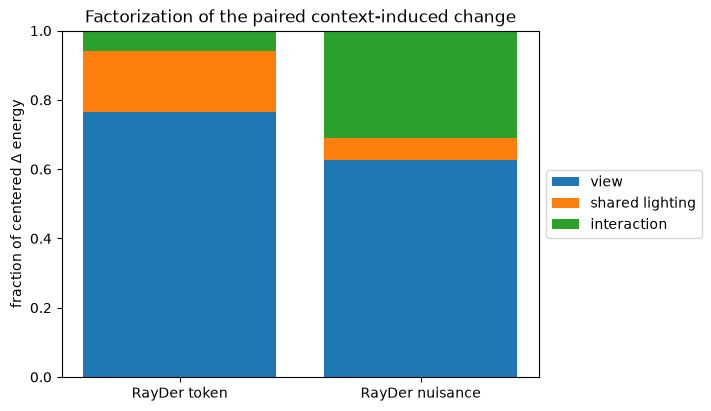

In [6]:
energy_labels = ("view", "shared lighting", "interaction")
delta_results = {}
for name, (independent_values, context_values) in paired_features.items():
    delta = context_values - independent_values
    energy, closure = two_factor_energy(delta)
    centered = independent_values - independent_values.mean((0, 1))
    relative_rms = delta.square().sum(-1).mean().sqrt() / centered.square().sum(-1).mean().sqrt()
    cosine = torch.nn.functional.cosine_similarity(independent_values, context_values, dim=-1).mean()
    delta_results[name] = {"fraction": energy / energy.sum(), "relative RMS": relative_rms, "cosine": cosine}
    print(f"{name}: RMS Δ / independent spread={relative_rms:.3f}, mean cosine={cosine:.3f}, closure={closure:.2e}")

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
bottom = torch.zeros(len(delta_results))
for component, label in enumerate(energy_labels):
    values = torch.stack([result["fraction"][component] for result in delta_results.values()])
    ax.bar(list(delta_results), values, bottom=bottom, label=label); bottom += values
ax.set(title="Factorization of the paired context-induced change", ylabel="fraction of centered Δ energy", ylim=(0, 1))
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()


## 2. Does context improve lighting factorization?

Every representation is decomposed on the complete balanced grid as

$$z_{vi}=\mu+a_v+b_i+r_{vi},$$

where $a_v$ is the camera effect, $b_i$ is the lighting effect shared across cameras, and $r_{vi}$ is their interaction. These sum-to-zero terms are orthogonal in the balanced design. Fractions of centered native-coordinate energy permit comparison across dimensions and scales. Evidence for improved factorization is an increased shared-lighting fraction together with reduced interaction, not merely a changed latent.


representation                       view   lighting  interaction     closure
-----------------------------------------------------------------------------
RayDer token · independent          0.714      0.142        0.143    0.00e+00
RayDer token · context              0.802      0.140        0.058    2.68e-16
RayDer nuisance · independent       0.688      0.087        0.225    1.44e-16
RayDer nuisance · context           0.689      0.080        0.231    0.00e+00
DINOv3 · per image                  0.488      0.167        0.345    1.92e-16


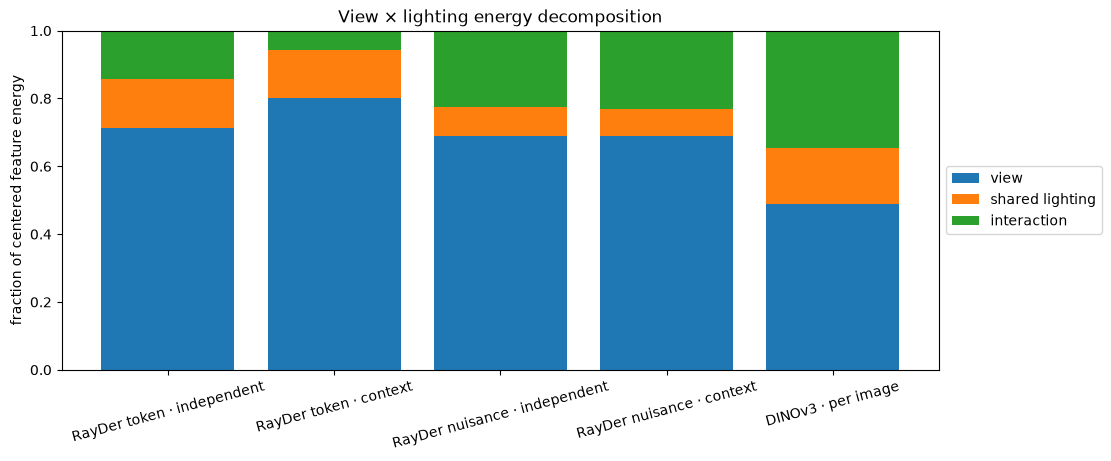

In [7]:
energy_results = {name: two_factor_energy(values) for name, values in features.items()}
header = f"{'representation':<31} {'view':>9} {'lighting':>10} {'interaction':>12} {'closure':>11}"
print(header); print("-" * len(header))
for name, (energy, closure) in energy_results.items():
    fraction = energy / energy.sum()
    print(f"{name:<31} {fraction[0]:>9.3f} {fraction[1]:>10.3f} {fraction[2]:>12.3f} {closure:>11.2e}")

fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
bottom = torch.zeros(len(features))
for component, label in enumerate(energy_labels):
    values = torch.stack([result[0][component] / result[0].sum() for result in energy_results.values()])
    ax.bar(list(features), values, bottom=bottom, label=label); bottom += values
ax.set(title="View × lighting energy decomposition", ylabel="fraction of centered feature energy", ylim=(0, 1))
ax.tick_params(axis="x", rotation=15); ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()


## 3. Does context improve cross-view lighting geometry?

For representation $r$, each view supplies a standardized pairwise distance vector

$$d_{r,v}(i,j)=\|\tilde z^r_{vi}-\tilde z^r_{vj}\|_2,$$

and $G_r(v,u)=\rho_S(d_{r,v},d_{r,u})$ measures agreement of lighting-distance **rankings**. This deliberately avoids claiming functional equivalence.

Absolute overall and Dirichlet-stratified heatmaps are retained for diagnostic inspection. The compact relative plot reports contextual minus independent mean off-diagonal agreement. Physical interpretability is summarized by $\rho(d_r,d_{illum})$ and $\rho(d_r,d_{illum}\mid d_{image})$. Pairwise correlations are descriptive because pairs share samples.


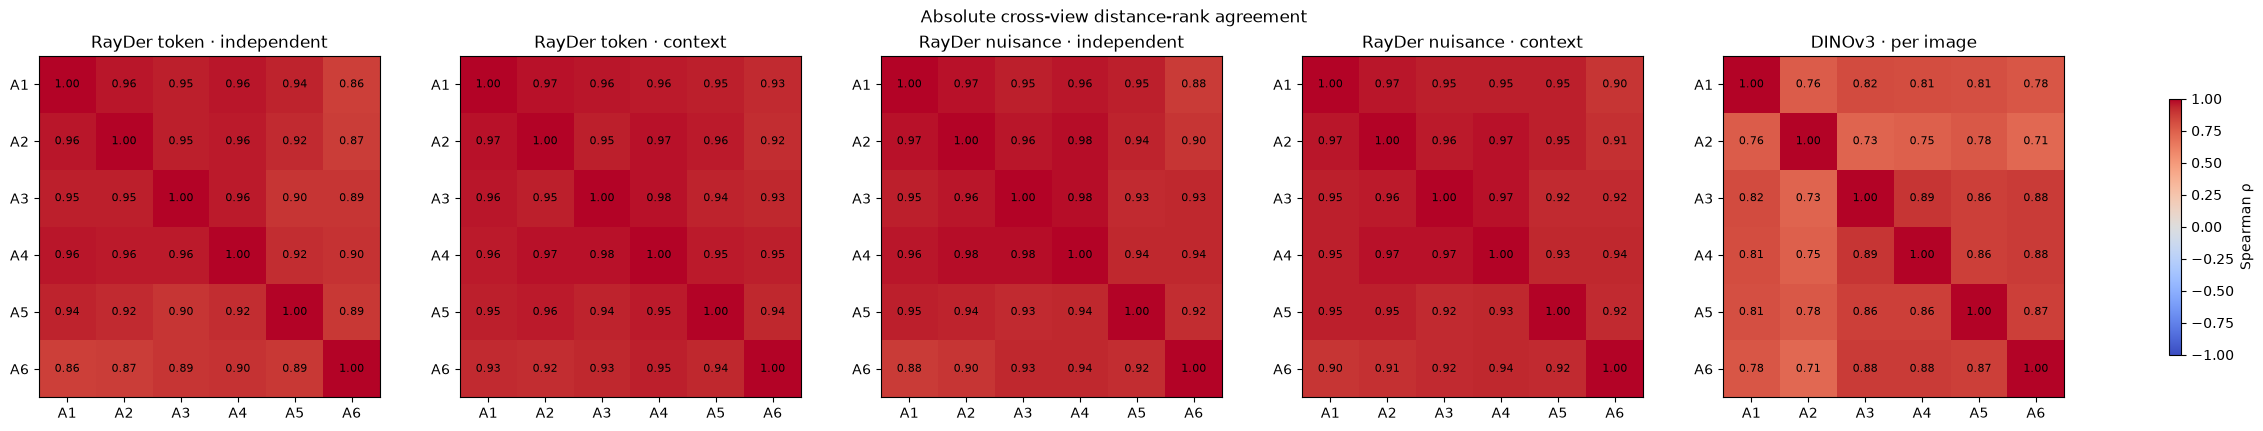

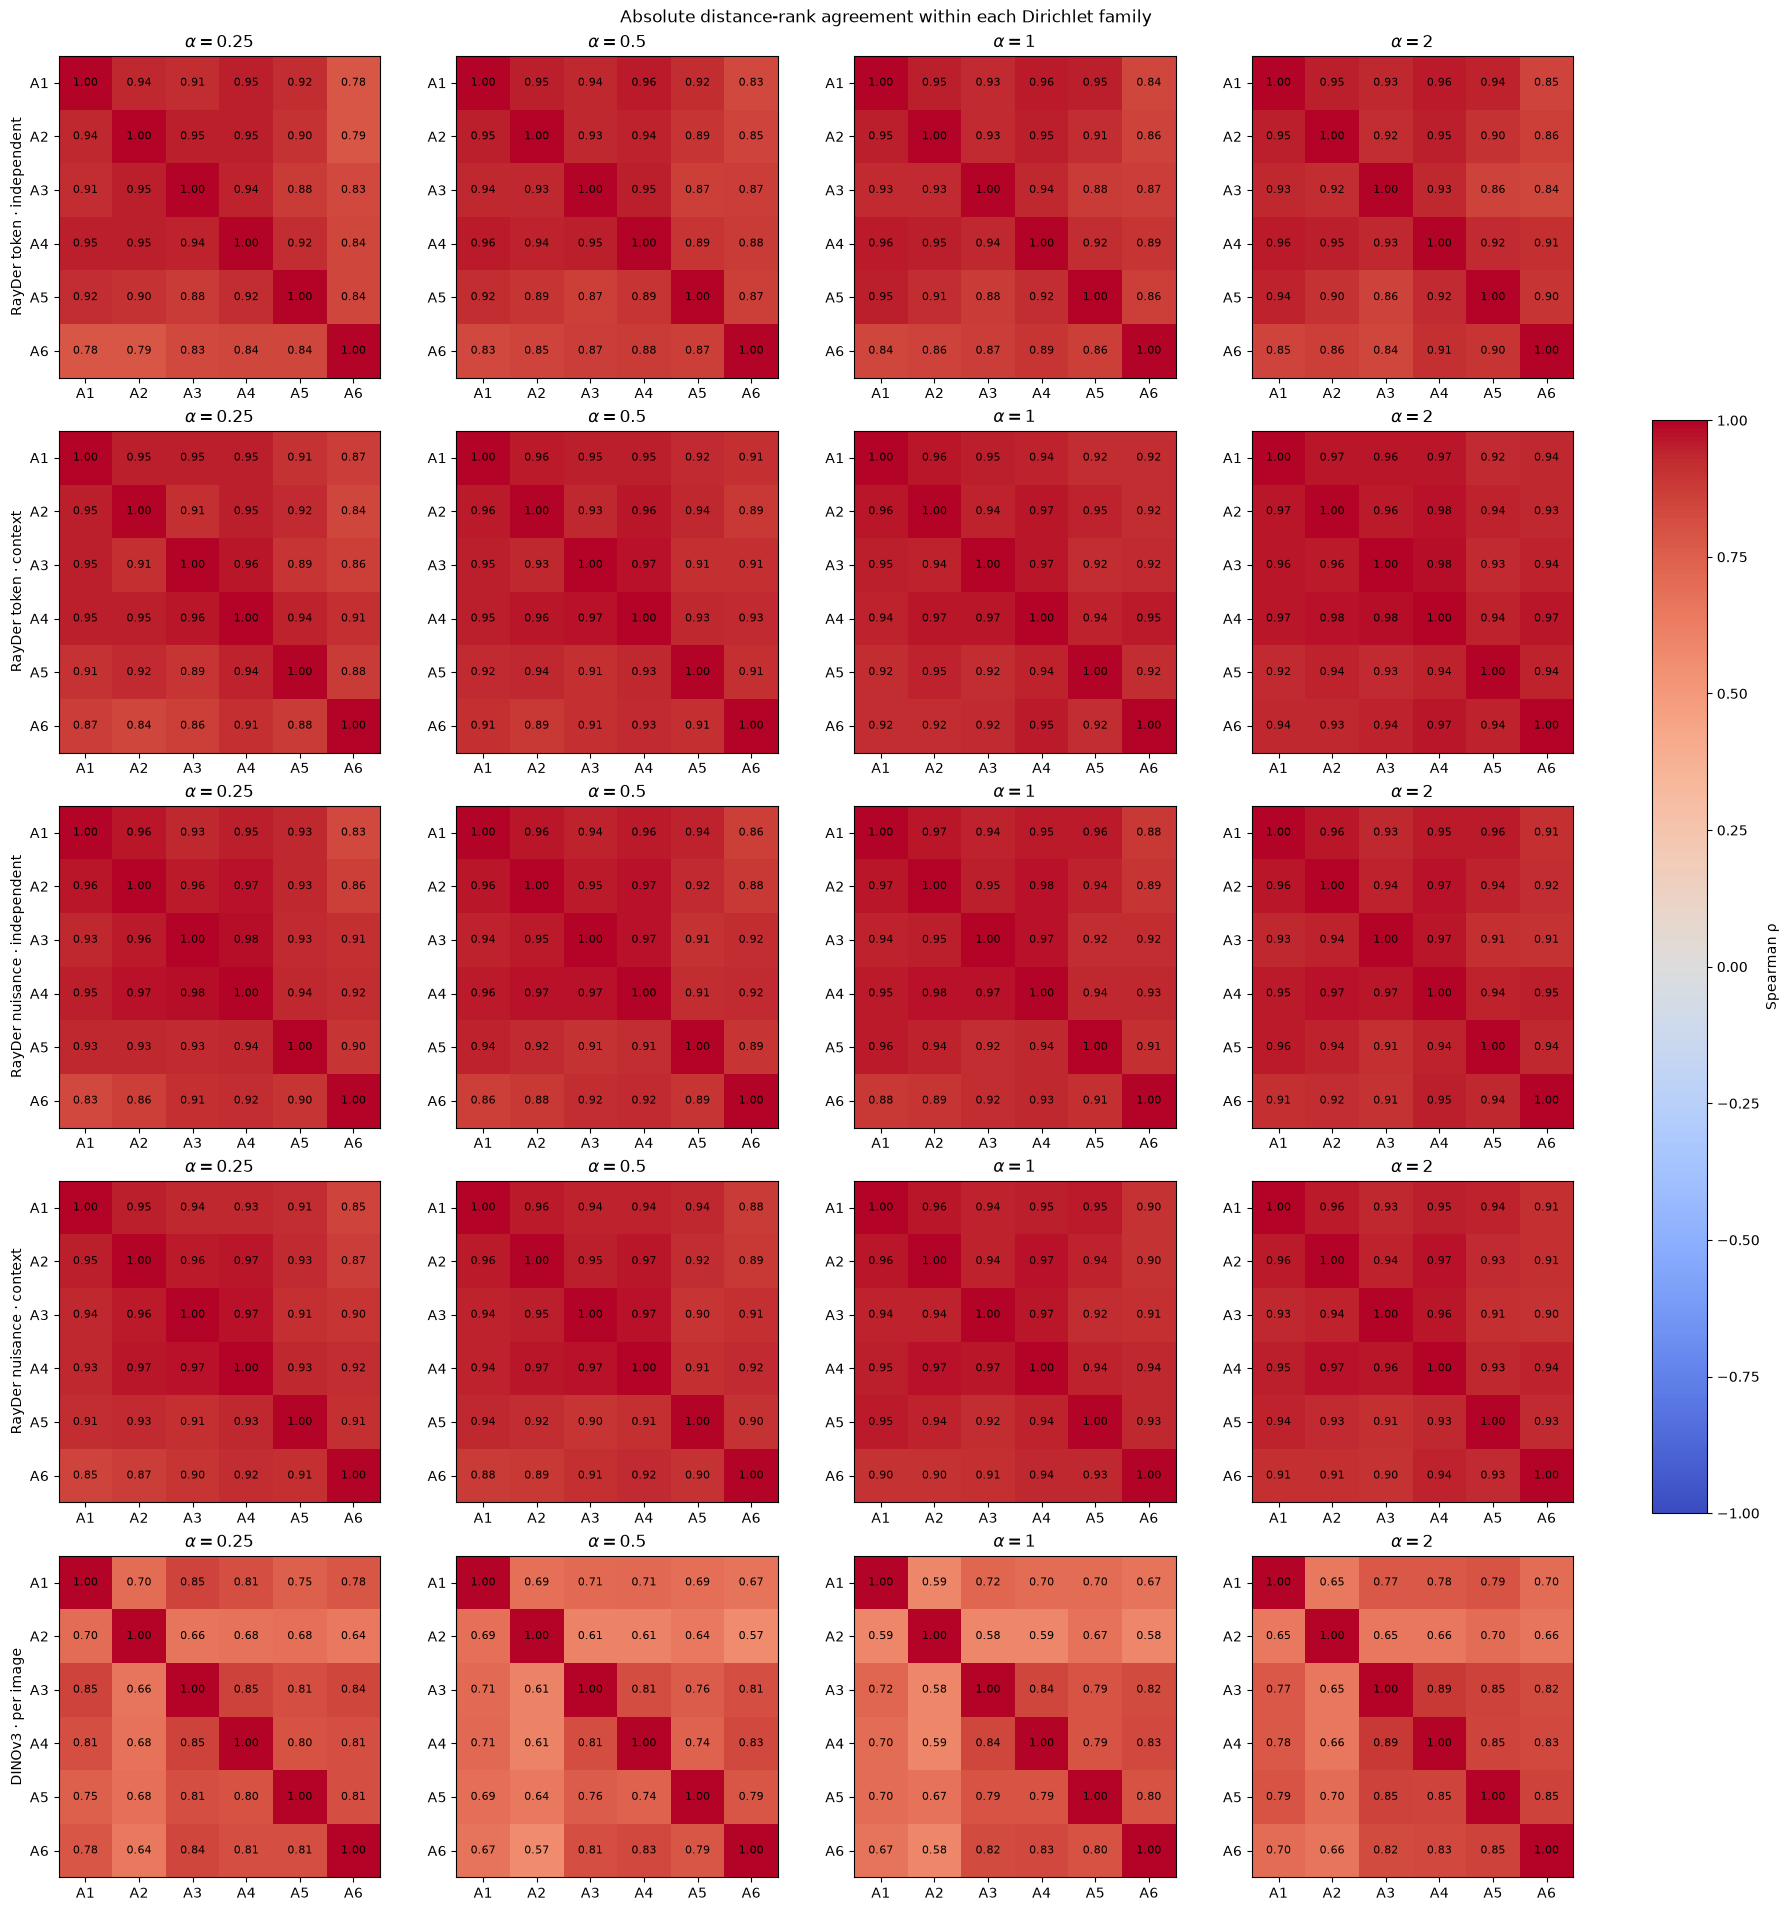

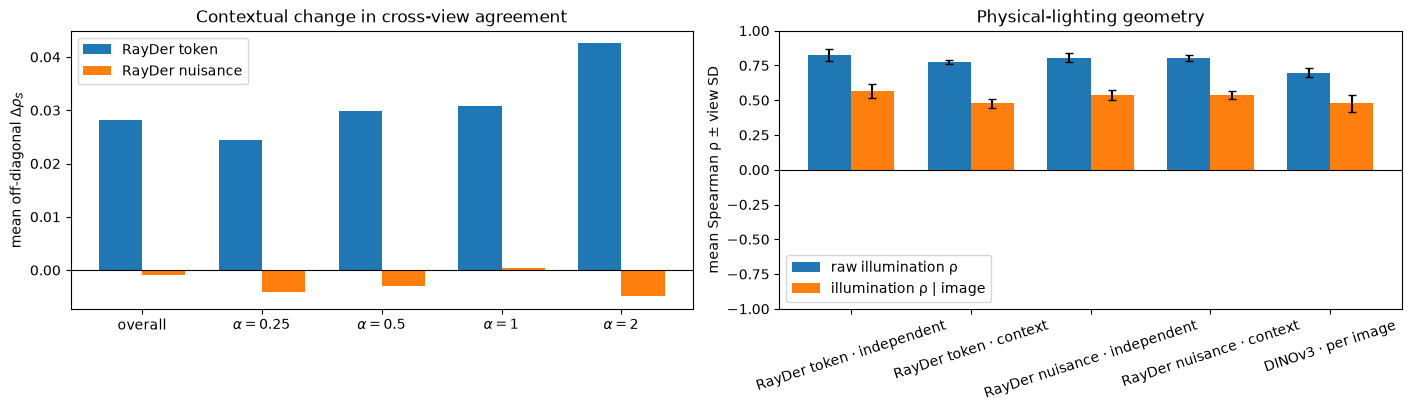

In [8]:
view_pairs = list(combinations(range(len(CAMERAS)), 2))
pair_rows, pair_columns = torch.triu_indices(len(CAMERAS), len(CAMERAS), 1)
agreement_matrices, family_agreement_matrices, geometry_metrics = {}, {}, {}
for name, values in features.items():
    standardized = [standardize(view) for view in values]
    distances = [torch.pdist(view) for view in standardized]
    agreement = torch.eye(len(CAMERAS))
    for first, second in view_pairs:
        agreement[first, second] = agreement[second, first] = spearman(distances[first], distances[second])
    agreement_matrices[name] = agreement
    family_matrices = []
    for alpha in families:
        selected = mixture_family == alpha
        family_distances = [torch.pdist(view[selected]) for view in standardized]
        matrix = torch.eye(len(CAMERAS))
        for first, second in view_pairs:
            matrix[first, second] = matrix[second, first] = spearman(family_distances[first], family_distances[second])
        family_matrices.append(matrix)
    family_agreement_matrices[name] = torch.stack(family_matrices)
    geometry_metrics[name] = {
        "rho illumination": torch.tensor([spearman(distance, illumination_distances) for distance in distances]),
        "rho image": torch.tensor([spearman(distance, image_distances[v]) for v, distance in enumerate(distances)]),
        "partial rho": torch.tensor([
            partial_spearman(distance, illumination_distances, image_distances[v])
            for v, distance in enumerate(distances)
        ]),
    }

fig, axes = plt.subplots(1, len(features), figsize=(23, 4.2), constrained_layout=True)
for ax, (name, matrix) in zip(axes, agreement_matrices.items()):
    image = annotated_heatmap(ax, matrix, CAMERAS, title=name, cmap="coolwarm", vmin=-1, vmax=1)
fig.suptitle("Absolute cross-view distance-rank agreement")
fig.colorbar(image, ax=axes, label="Spearman ρ", shrink=0.75)
plt.show()

fig, axes = plt.subplots(len(features), len(families), figsize=(18, 19), constrained_layout=True)
for row, (name, matrices) in enumerate(family_agreement_matrices.items()):
    for column, (alpha, matrix) in enumerate(zip(families, matrices)):
        image = annotated_heatmap(axes[row, column], matrix, CAMERAS, title=fr"$\alpha={alpha:g}$", cmap="coolwarm", vmin=-1, vmax=1)
        if column == 0: axes[row, column].set_ylabel(name)
fig.suptitle("Absolute distance-rank agreement within each Dirichlet family")
fig.colorbar(image, ax=axes, label="Spearman ρ", shrink=0.6)
plt.show()

def mean_off_diagonal(matrix):
    return matrix[..., pair_rows, pair_columns].mean(-1)

relative_labels = ["overall", *[fr"$\alpha={alpha:g}$" for alpha in families]]
relative_agreement = {}
for short_name, independent_name, context_name in (
    ("RayDer token", TOKEN_IND, TOKEN_CTX), ("RayDer nuisance", NUIS_IND, NUIS_CTX),
):
    absolute = torch.cat([
        mean_off_diagonal(agreement_matrices[context_name])[None],
        mean_off_diagonal(family_agreement_matrices[context_name]),
    ])
    baseline = torch.cat([
        mean_off_diagonal(agreement_matrices[independent_name])[None],
        mean_off_diagonal(family_agreement_matrices[independent_name]),
    ])
    relative_agreement[short_name] = absolute - baseline

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
x = torch.arange(len(relative_labels), dtype=torch.float32)
for offset, (name, values) in zip((-0.18, 0.18), relative_agreement.items()):
    axes[0].bar(x + offset, values, 0.36, label=name)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title="Contextual change in cross-view agreement", ylabel=r"mean off-diagonal $\Delta\rho_S$", xticks=x, xticklabels=relative_labels)
axes[0].legend()
for offset, (key, label) in zip((-0.18, 0.18), (("rho illumination", "raw illumination ρ"), ("partial rho", "illumination ρ | image"))):
    means = torch.stack([metrics[key].mean() for metrics in geometry_metrics.values()])
    errors = torch.stack([metrics[key].std() for metrics in geometry_metrics.values()])
    positions = torch.arange(len(features), dtype=torch.float32)
    axes[1].bar(positions + offset, means, 0.36, yerr=errors, capsize=3, label=label)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(title="Physical-lighting geometry", ylabel="mean Spearman ρ ± view SD", xticks=positions, xticklabels=list(features), ylim=(-1, 1))
axes[1].tick_params(axis="x", rotation=18); axes[1].legend()
plt.show()


## 4. Is the lighting coordinate map shared across views?

The unit-sum constraint leaves five orthonormal mixture contrasts $q_i$. On the common 80% training split, each view fits

$$z_{vi}\approx a_v+B_vq_i.$$

The view-specific reconstruction retains $B_v$; the common reconstruction replaces it with $\bar B=\frac16\sum_vB_v$ while retaining view offsets. Held-out-mixture $R^2$ tests whether illumination occupies the same **linear feature coordinates** across cameras, which is stricter than preserving distance rankings.

representation                   specific R2   common R2  common loss
---------------------------------------------------------------------
RayDer token · independent             0.760       0.379        0.381
RayDer token · context                 0.472       0.284        0.187
RayDer nuisance · independent          0.796       0.215        0.581
RayDer nuisance · context              0.746       0.180        0.566
DINOv3 · per image                     0.341       0.119        0.222


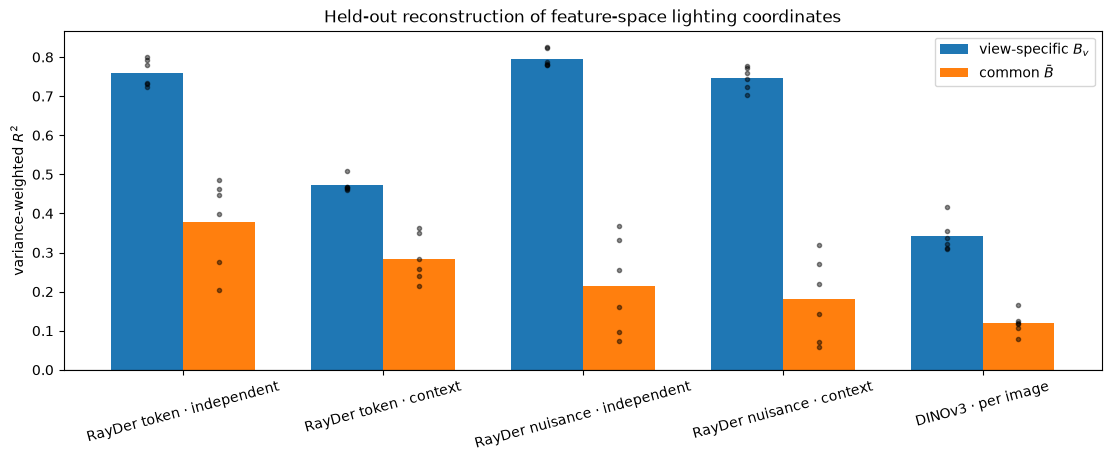

In [9]:
weight_basis = torch.linalg.svd(torch.ones(1, 6), full_matrices=True).Vh[1:].T
weight_coordinates = mixture_weights @ weight_basis
coordinate_mean = weight_coordinates[train_indices].mean(0)
x_train = weight_coordinates[train_indices] - coordinate_mean
x_test = weight_coordinates[test_indices] - coordinate_mean
map_results = {}
for name, values in features.items():
    offsets = values[:, train_indices].mean(1)
    maps = torch.stack([
        torch.linalg.lstsq(x_train, values[v, train_indices] - offsets[v]).solution
        for v in range(len(CAMERAS))
    ])
    common_map = maps.mean(0)
    specific = torch.stack([
        variance_weighted_r2(values[v, test_indices], offsets[v] + x_test @ maps[v]) for v in range(len(CAMERAS))
    ])
    common = torch.stack([
        variance_weighted_r2(values[v, test_indices], offsets[v] + x_test @ common_map) for v in range(len(CAMERAS))
    ])
    map_results[name] = specific, common

header = f"{'representation':<31} {'specific R2':>12} {'common R2':>11} {'common loss':>12}"
print(header); print("-" * len(header))
for name, (specific, common) in map_results.items():
    print(f"{name:<31} {specific.mean():>12.3f} {common.mean():>11.3f} {(specific - common).mean():>12.3f}")

fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
x = torch.arange(len(features), dtype=torch.float32)
for offset, index, label in ((-0.18, 0, r"view-specific $B_v$"), (0.18, 1, r"common $\bar B$")):
    scores = [result[index] for result in map_results.values()]
    ax.bar(x + offset, [score.mean() for score in scores], 0.36, label=label)
    for position, score in zip(x + offset, scores): ax.plot(torch.full_like(score, position), score, "k.", alpha=0.45)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="Held-out reconstruction of feature-space lighting coordinates", ylabel=r"variance-weighted $R^2$", xticks=x, xticklabels=list(features))
ax.tick_params(axis="x", rotation=15); ax.legend()
plt.show()


## 5. Does the result transfer to an unseen camera?

Every leave-one-camera-out fold trains a single ridge decoder on five cameras and the training mixtures, then evaluates the sixth camera on held-out mixtures. This simultaneously withholds illumination labels and a camera from probe fitting. A fixed $\alpha=10$ is applied after feature standardization for every row; no test result selects regularization.

The camera-centered variant subtracts each camera's mean over **training mixtures only**. The held-out camera therefore receives unlabeled calibration images. For contextual features, its image was present during RayDer inference even though its labels and features were excluded from probe fitting; this is transfer of the contextual token coordinate system, not feature-extractor-level camera exclusion.


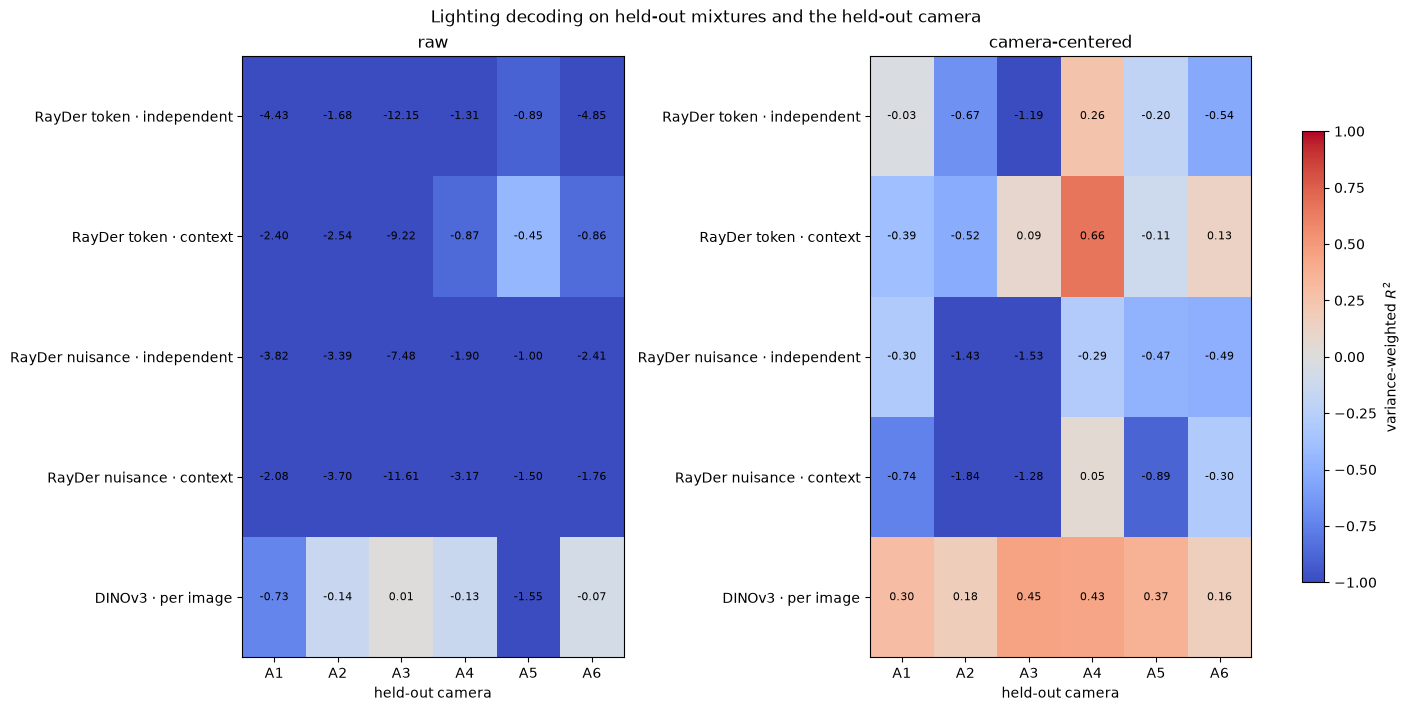

In [10]:
def fit_probe(x, y):
    probe = make_pipeline(StandardScaler(), Ridge(alpha=RIDGE_ALPHA))
    probe.fit(x.numpy(), y.numpy())
    return probe

def predict_probe(probe, x):
    return torch.from_numpy(probe.predict(x.numpy())).to(x)

def direct_camera_fold(values, held_out_view, center):
    values = values.double()
    if center: values = values - values[:, train_indices].mean(1, keepdim=True)
    training_views = view_indices[view_indices != held_out_view]
    x_train = values[training_views][:, train_indices].flatten(0, 1)
    y_train = weight_coordinates[train_indices].double().repeat(len(training_views), 1)
    probe = fit_probe(x_train, y_train)
    prediction = predict_probe(probe, values[held_out_view, test_indices])
    return variance_weighted_r2(weight_coordinates[test_indices].double(), prediction)

direct_results = {
    name: {
        variant: torch.stack([direct_camera_fold(values, held_out, center) for held_out in view_indices])
        for variant, center in (("raw", False), ("camera-centered", True))
    }
    for name, values in features.items()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, variant in zip(axes, ("raw", "camera-centered")):
    matrix = torch.stack([result[variant] for result in direct_results.values()])
    image = ax.imshow(matrix, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    for row in range(len(features)):
        for column in view_indices: ax.text(column, row, f"{matrix[row, column]:.2f}", ha="center", va="center", fontsize=8)
    ax.set(title=variant, xlabel="held-out camera", xticks=view_indices, xticklabels=CAMERAS,
           yticks=range(len(features)), yticklabels=list(features))
fig.suptitle("Lighting decoding on held-out mixtures and the held-out camera")
fig.colorbar(image, ax=axes, label=r"variance-weighted $R^2$", shrink=0.75)
plt.show()


## Linear-pixel lighting ceilings

The pixels are analytic exposure-scaled linear OLAT mixtures before display encoding and clipping, matching the image-distance reference rather than the clipped sRGB tensor received by the backbones.

Two affine controls delimit how much lighting information is available in the input. The **local** control fits a separate probe to each camera's flattened, masked linear-RGB image. The **all-view** control concatenates all six images before fitting one mixture-level probe, matching the information available to a joint RayDer call without introducing learned multi-view processing.

Both are evaluated on the same held-out mixtures. Because $x_v(w)=w^\top B_v$, their kernels are computed exactly from the OLAT basis Gram matrices and ridge is solved in the training-sample dimension. These are image-formation ceilings rather than additional latent rows; energy, geometry, and pose measurements do not apply to them.


local linear-pixel R²: {'A1': 0.9999999999999927, 'A2': 0.9999999999999883, 'A3': 0.9999999999999915, 'A4': 0.999999999999981, 'A5': 0.9999999999999916, 'A6': 0.9999999999999859}
all-view concatenated linear pixels: R²=1.000000


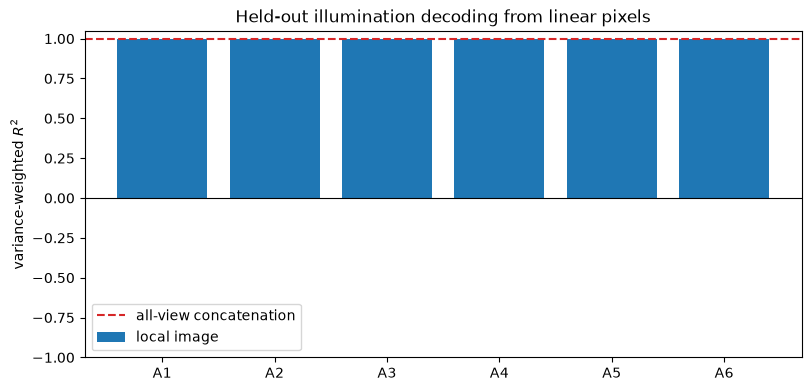

In [11]:
from notebooks.common import dual_ridge_predict, pixel_basis_gram, view_weight_coefficients

screen_gram = pixel_basis_gram(basis_pixels)
local_coefficients = view_weight_coefficients(mixture_weights, len(CAMERAS)).double()

def pixel_kernel_prediction(train_coefficients, test_coefficients, gram):
    train_kernel = train_coefficients @ gram @ train_coefficients.T
    test_train_kernel = test_coefficients @ gram @ train_coefficients.T
    return dual_ridge_predict(train_kernel, test_train_kernel, weight_coordinates[train_indices])

pixel_local_r2 = torch.stack([
    variance_weighted_r2(
        weight_coordinates[test_indices].double(),
        pixel_kernel_prediction(local_coefficients[view, train_indices], local_coefficients[view, test_indices], screen_gram),
    )
    for view in view_indices
])

channels_per_view = basis_pixels.shape[-1]
joint_gram = torch.block_diag(*[
    basis_pixels[view] @ basis_pixels[view].T / (len(CAMERAS) * channels_per_view)
    for view in view_indices
])
joint_coefficients = mixture_weights.double().repeat(1, len(CAMERAS))
joint_prediction = pixel_kernel_prediction(
    joint_coefficients[train_indices], joint_coefficients[test_indices], joint_gram,
)
pixel_joint_r2 = variance_weighted_r2(weight_coordinates[test_indices].double(), joint_prediction)
print("local linear-pixel R²:", dict(zip(CAMERAS, pixel_local_r2.tolist())))
print(f"all-view concatenated linear pixels: R²={pixel_joint_r2:.6f}")

fig, ax = plt.subplots(figsize=(8, 3.8), constrained_layout=True)
ax.bar(CAMERAS, pixel_local_r2, label="local image")
ax.axhline(pixel_joint_r2, color="tab:red", linestyle="--", label="all-view concatenation")
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="Held-out illumination decoding from linear pixels", ylabel=r"variance-weighted $R^2$", ylim=(-1, 1.05))
ax.legend()
plt.show()


## 6. Pose stability and leave-one-camera-out gauge

A fixed physical camera should yield a stable prediction as lighting changes. Rotation leakage is geodesic distance to the mean predicted rotation, translation leakage is distance to the componentwise median, and focal leakage is relative deviation from the median. The plot reports the 95th percentile per camera and over all camera--mixture observations.

RayDer's self-supervised pose has a free global gauge. Separately for every held-out camera and training mixture, the predicted six-camera set is aligned to ground truth using only the other five cameras. Heatmap rows identify the camera excluded from the gauge fit; columns identify the evaluated camera. The diagonal is the strict pose-transfer diagnostic used to validate the predicted rotations below.


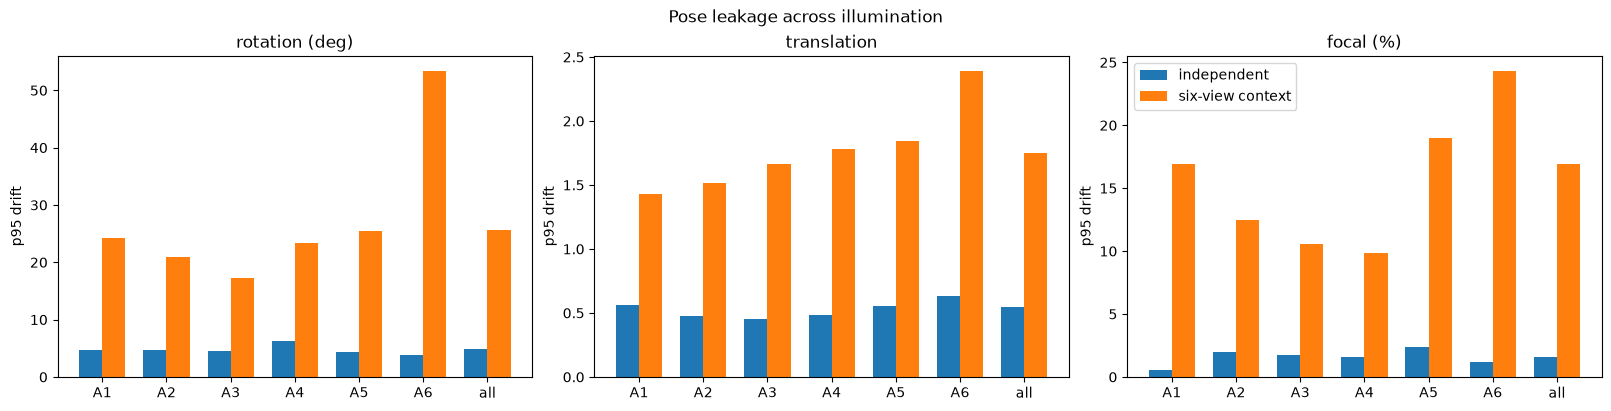

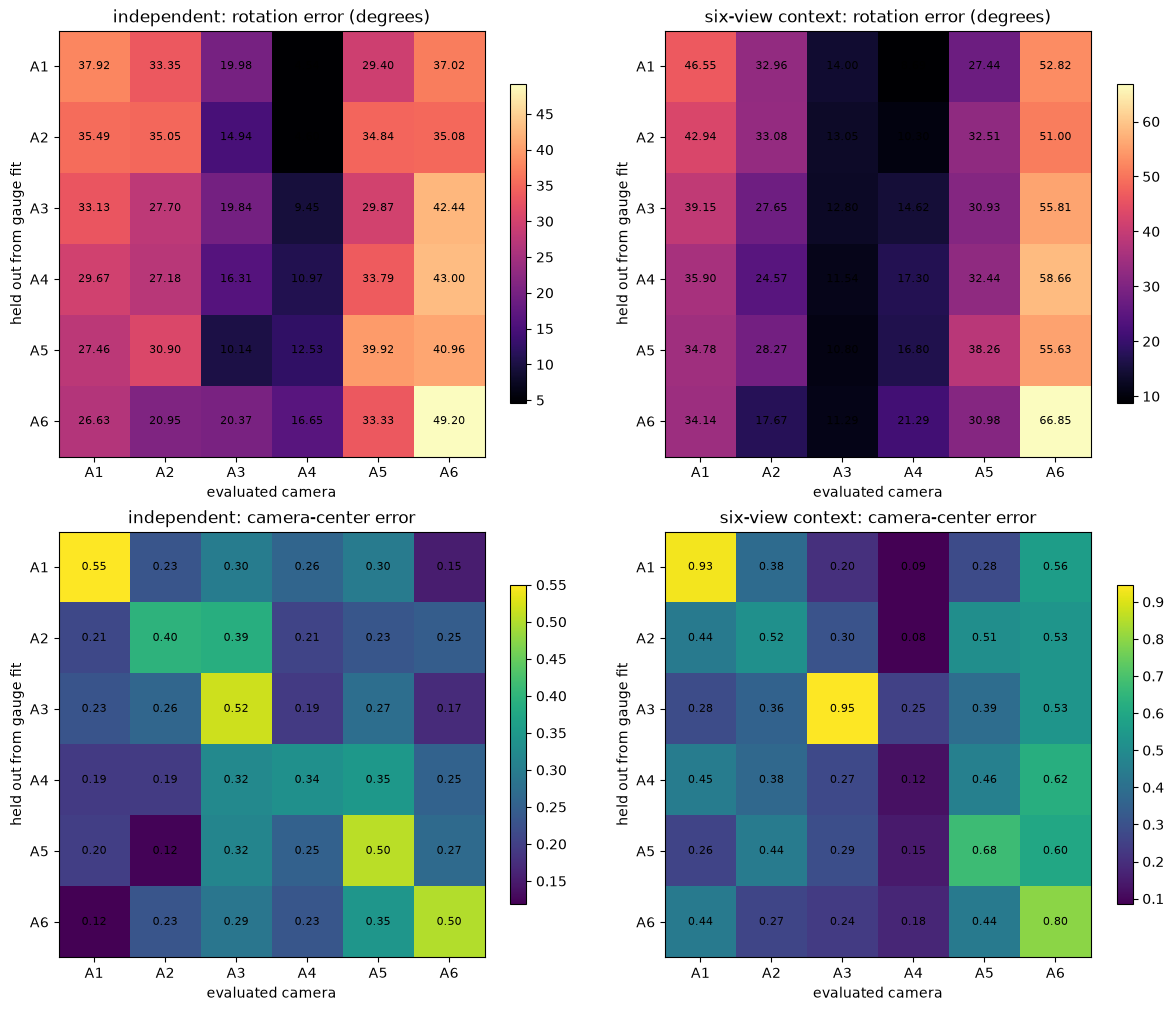

In [12]:
pose_conditions = {"independent": independent, "six-view context": context}
pose_leakage = {}
for condition, values in pose_conditions.items():
    rotation_rows, translation_rows, focal_rows = [], [], []
    for view in view_indices:
        rotations = Rotation.from_matrix(values["rotation"][view].numpy())
        rotation_rows.append(torch.from_numpy(np.rad2deg((rotations.mean().inv() * rotations).magnitude())))
        translations = values["translation"][view]
        translation_rows.append(torch.linalg.vector_norm(translations - translations.median(0).values, dim=1))
        focals = values["focal"][view].squeeze(-1)
        focal_rows.append(100 * (focals - focals.median()).abs() / focals.median().abs().clamp_min(1e-8))
    pose_leakage[condition] = {
        "rotation (deg)": torch.stack(rotation_rows),
        "translation": torch.stack(translation_rows),
        "focal (%)": torch.stack(focal_rows),
    }

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
x = torch.arange(len(CAMERAS) + 1, dtype=torch.float32)
for ax, metric in zip(axes, ("rotation (deg)", "translation", "focal (%)")):
    for offset, (condition, metrics) in zip((-0.18, 0.18), pose_leakage.items()):
        values = metrics[metric]
        summary = torch.cat([values.quantile(0.95, dim=1), values.flatten().quantile(0.95)[None]])
        ax.bar(x + offset, summary, 0.36, label=condition)
    ax.set(title=metric, ylabel="p95 drift", xticks=x, xticklabels=(*CAMERAS, "all"))
axes[-1].legend(); fig.suptitle("Pose leakage across illumination")
plt.show()

ground_truth_rotations = torch.stack([
    torch.tensor(dataset.camera_metadata(camera)["transform_matrix"], dtype=torch.double)[:3, :3]
    for camera in CAMERAS
])
ground_truth_translations = torch.stack([
    torch.tensor(dataset.camera_metadata(camera)["transform_matrix"], dtype=torch.double)[:3, 3]
    for camera in CAMERAS
])

def project_to_so3(matrix):
    u, _, vh = torch.linalg.svd(matrix)
    correction = torch.eye(3, dtype=matrix.dtype)
    correction[-1, -1] = torch.det(u @ vh)
    return u @ correction @ vh

def align_rotation_set(predicted, reference, fitting_views):
    cross = sum(reference[v] @ predicted[v].T for v in fitting_views)
    gauge = project_to_so3(cross)
    return gauge @ predicted

def rotation_error_degrees(estimate, target):
    relative = estimate.transpose(-1, -2) @ target
    cosine = ((relative.diagonal(dim1=-2, dim2=-1).sum(-1) - 1) / 2).clamp(-1, 1)
    return torch.rad2deg(torch.acos(cosine))

def align_centers(predicted, reference, fitting_views):
    source, target = predicted[fitting_views], reference[fitting_views]
    source_mean, target_mean = source.mean(0), target.mean(0)
    source_centered, target_centered = source - source_mean, target - target_mean
    rotation = project_to_so3(target_centered.T @ source_centered)
    rotated = (rotation @ source_centered.T).T
    scale = (target_centered * rotated).sum() / source_centered.square().sum()
    translation = target_mean - scale * (rotation @ source_mean)
    return (scale * (rotation @ predicted.T)).T + translation

rotation_error_matrices, position_error_matrices, predicted_rotations_by_condition = {}, {}, {}
for condition, values in pose_conditions.items():
    rotations, translations = values["rotation"].double(), values["translation"].double()
    aligned_rotations, aligned_positions = [], []
    for held_out in view_indices:
        fitting_views = view_indices[view_indices != held_out]
        aligned_rotations.append(torch.stack([
            align_rotation_set(rotations[:, mixture], ground_truth_rotations, fitting_views)
            for mixture in train_indices
        ]))
        aligned_positions.append(torch.stack([
            align_centers(translations[:, mixture], ground_truth_translations, fitting_views)
            for mixture in train_indices
        ]))
    aligned_rotations, aligned_positions = torch.stack(aligned_rotations), torch.stack(aligned_positions)
    rotation_error_matrices[condition] = rotation_error_degrees(
        aligned_rotations, ground_truth_rotations[None, None]
    ).mean(1)
    position_error_matrices[condition] = torch.linalg.vector_norm(
        aligned_positions - ground_truth_translations[None, None], dim=-1
    ).mean(1)
    predicted_rotations_by_condition[condition] = torch.stack([
        torch.stack([project_to_so3(aligned_rotations[held_out, :, view].mean(0)) for view in view_indices])
        for held_out in view_indices
    ])

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for column, condition in enumerate(pose_conditions):
    for row, (matrices, title, cmap) in enumerate((
        (rotation_error_matrices, "rotation error (degrees)", "magma"),
        (position_error_matrices, "camera-center error", "viridis"),
    )):
        matrix = matrices[condition]
        image = axes[row, column].imshow(matrix, cmap=cmap)
        for i in view_indices:
            for j in view_indices: axes[row, column].text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=8)
        axes[row, column].set(title=f"{condition}: {title}", xlabel="evaluated camera", ylabel="held out from gauge fit",
                              xticks=view_indices, xticklabels=CAMERAS, yticks=view_indices, yticklabels=CAMERAS)
        fig.colorbar(image, ax=axes[row, column], shrink=0.75)
plt.show()


## 7. Geometry-aware illumination decoding

Lamp weights do not transform continuously under arbitrary 3D rotation. We therefore represent mixture $w$ by its first directional moment and symmetric trace-free second moment,

$$m(w)=\sum_k w_k\ell_k,\qquad Q(w)=\sum_k w_k(\ell_k\ell_k^\top-I/3).$$

These are the $l=1$ and $l=2$ real spherical-harmonic components. For camera-to-world rotation $R$, $m_c=R^\top m_w$ and $Q_c=R^\top Q_wR$. For the approximately antipodal axial lamps, these moments plus unit sum recover all five weight contrasts; the rank and round-trip assertions verify that statement for the selected measured directions.

Each fold learns camera-centered features $\rightarrow$ camera-frame moments on five cameras, rotates the held-out-camera prediction back to the world frame, and scores recovered weight contrasts on held-out mixtures. Oracle rotations contrast representation quality. Each RayDer row additionally uses its own condition-matched predicted rotations. DINO receives only the oracle geometry; a DINO--RayDer hybrid would confound the control.


augmented lamp-moment rank: 6


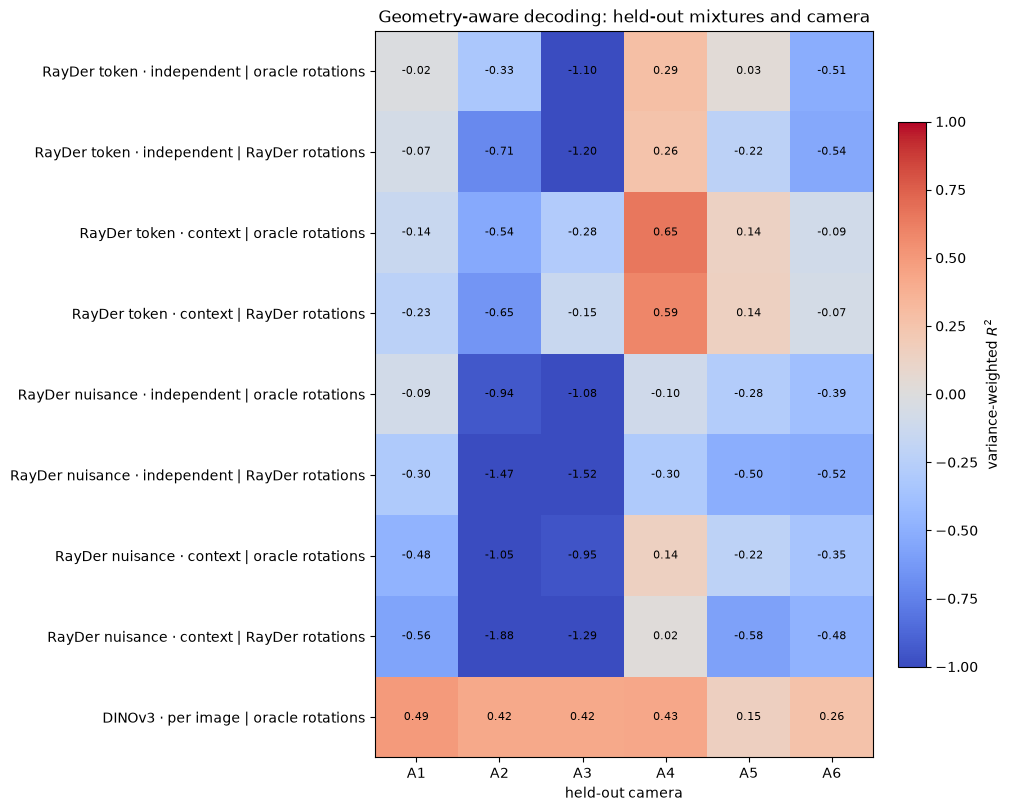

In [13]:
directions = selected_directions.double()
identity = torch.eye(3, dtype=torch.double)
second_moments = torch.einsum("ni,nj->nij", directions, directions) - identity / 3
anchor_moments = torch.cat([directions, second_moments.flatten(1)], dim=1)
augmented_anchor_moments = torch.cat([torch.ones(6, 1, dtype=torch.double), anchor_moments], dim=1)
assert torch.linalg.matrix_rank(augmented_anchor_moments) == 6
moment_inverse = torch.linalg.pinv(augmented_anchor_moments)
reference_weights = mixture_weights[train_indices].double().mean(0)
world_moments = (mixture_weights.double() - reference_weights) @ anchor_moments

def moments_world_to_camera(descriptors, rotations):
    first, second = descriptors[:, :3], descriptors[:, 3:].reshape(-1, 3, 3)
    first_camera = torch.einsum("vwc,mw->vmc", rotations, first)
    second_camera = torch.einsum("vwc,mwx,vxd->vmcd", rotations, second, rotations)
    return torch.cat([first_camera, second_camera.flatten(2)], dim=-1)

def moments_camera_to_world(descriptors, rotations):
    first = descriptors[..., :3]
    second = descriptors[..., 3:].reshape(*descriptors.shape[:-1], 3, 3)
    first_world = torch.einsum("vwc,vmc->vmw", rotations, first)
    second_world = torch.einsum("vwc,vmcd,vxd->vmwx", rotations, second, rotations)
    return torch.cat([first_world, second_world.flatten(-2)], dim=-1)

def world_moments_to_coordinates(descriptors):
    augmented = torch.cat([torch.zeros(*descriptors.shape[:-1], 1, dtype=descriptors.dtype), descriptors], dim=-1)
    recovered_weights = reference_weights + augmented @ moment_inverse
    return recovered_weights @ weight_basis.double()

assert torch.allclose(world_moments_to_coordinates(world_moments), weight_coordinates.double(), atol=1e-7)
camera_round_trip = moments_world_to_camera(world_moments, ground_truth_rotations)
assert torch.allclose(
    moments_camera_to_world(camera_round_trip, ground_truth_rotations),
    world_moments.expand(len(CAMERAS), -1, -1), atol=1e-7,
)
print("augmented lamp-moment rank:", torch.linalg.matrix_rank(augmented_anchor_moments).item())

def geometry_camera_fold(values, rotations, held_out_view):
    values = values.double() - values[:, train_indices].double().mean(1, keepdim=True)
    camera_moments = moments_world_to_camera(world_moments, rotations)
    training_views = view_indices[view_indices != held_out_view]
    x_train = values[training_views][:, train_indices].flatten(0, 1)
    y_train = camera_moments[training_views][:, train_indices].flatten(0, 1)
    probe = fit_probe(x_train, y_train)
    camera_prediction = predict_probe(probe, values[held_out_view, test_indices])[None]
    world_prediction = moments_camera_to_world(camera_prediction, rotations[held_out_view, None])
    prediction = world_moments_to_coordinates(world_prediction).squeeze(0)
    return variance_weighted_r2(weight_coordinates[test_indices].double(), prediction)

geometry_results = {}
for name, values in features.items():
    geometry_results[(name, "oracle rotations")] = torch.stack([
        geometry_camera_fold(values, ground_truth_rotations, held_out) for held_out in view_indices
    ])
    if name != DINO:
        condition = "six-view context" if "context" in name else "independent"
        geometry_results[(name, "RayDer rotations")] = torch.stack([
            geometry_camera_fold(values, predicted_rotations_by_condition[condition][held_out], held_out)
            for held_out in view_indices
        ])

row_labels = [f"{name} | {source}" for name, source in geometry_results]
matrix = torch.stack(list(geometry_results.values()))
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
image = ax.imshow(matrix, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
for row in range(len(row_labels)):
    for column in view_indices: ax.text(column, row, f"{matrix[row, column]:.2f}", ha="center", va="center", fontsize=8)
ax.set(title="Geometry-aware decoding: held-out mixtures and camera", xlabel="held-out camera",
       xticks=view_indices, xticklabels=CAMERAS, yticks=range(len(row_labels)), yticklabels=row_labels)
fig.colorbar(image, ax=ax, label=r"variance-weighted $R^2$", shrink=0.75)
plt.show()


## 8. Temporal-rank sensitivity on continuous mixtures

RayDer assigns each input view a temporal coordinate. This diagnostic uses six mixtures from every Dirichlet family and several random permutations:

- **views + ranks together:** reorder the sequence while preserving each camera's original rank; this is a sequence-equivariance control;
- **ranks reassigned:** reorder images but retain ranks `0..5` by sequence position, deliberately changing camera-to-rank assignment.

Outputs are restored to camera order before comparison with the fixed-order reference. Token and nuisance drift are normalized by their reference spread; rotation drift is geodesic.

This test uses sampled continuous conditions rather than one-hot anchors and remains an architectural sensitivity diagnostic, not a lighting-quality score.


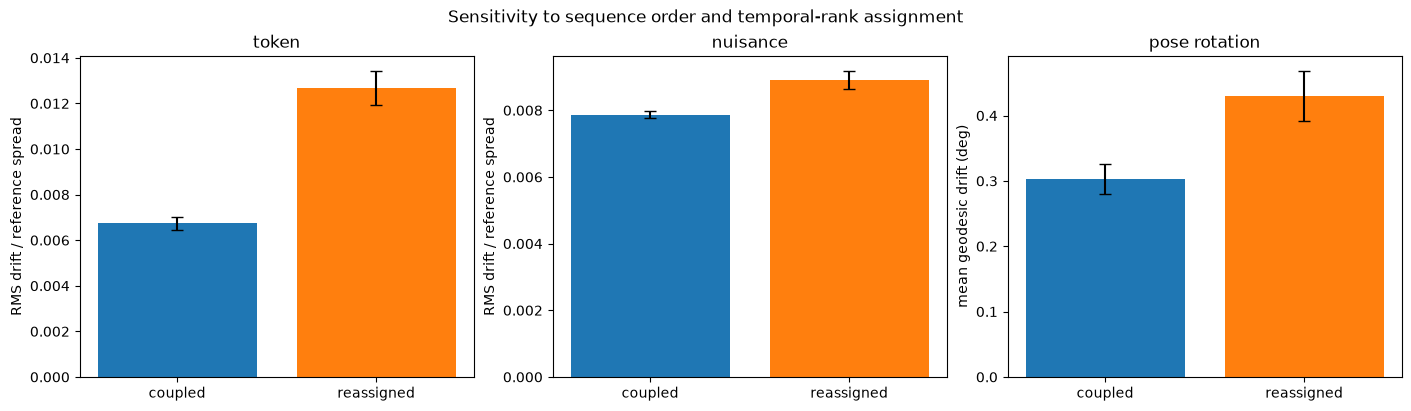

In [14]:
order_indices = torch.cat([torch.where(mixture_family == alpha)[0][:ORDER_SAMPLES_PER_FAMILY] for alpha in families])
order_images = dataset.render_weight_batch(
    mixture_weights[order_indices].numpy(), cameras=CAMERAS, light_indices=light_indices.numpy(),
    size=RESOLUTION, center_crop=True, exposure_ev=EXPOSURE_EV, mask=MASK,
    subtract_background=SUBTRACT_BACKGROUND,
)
reference = infer_context(order_images)
permutation_generator = torch.Generator().manual_seed(SEED + 2)
permutations = [torch.randperm(len(CAMERAS), generator=permutation_generator) for _ in range(NUM_ORDER_PERMUTATIONS)]
order_drift = {mode: {name: [] for name in ("token", "nuisance", "rotation")} for mode in ("views + ranks together", "ranks reassigned")}
for order in permutations:
    alternatives = {
        "views + ranks together": infer_context(order_images, order, fixed_temporal_ranks[order]),
        "ranks reassigned": infer_context(order_images, order, fixed_temporal_ranks),
    }
    for mode, values in alternatives.items():
        for name in ("token", "nuisance"):
            scale = (reference[name] - reference[name].mean((0, 1))).square().sum(-1).mean().sqrt()
            drift = (values[name] - reference[name]).square().sum(-1).mean().sqrt() / scale
            order_drift[mode][name].append(drift)
        order_drift[mode]["rotation"].append(rotation_error_degrees(values["rotation"], reference["rotation"]).mean())

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, metric, title in zip(axes, ("token", "nuisance", "rotation"), ("token", "nuisance", "pose rotation")):
    for column, (mode, metrics) in enumerate(order_drift.items()):
        values = torch.stack(metrics[metric])
        ax.bar(column, values.mean(), yerr=values.std(), capsize=4)
    unit = "mean geodesic drift (deg)" if metric == "rotation" else "RMS drift / reference spread"
    ax.set(title=title, ylabel=unit, xticks=range(2), xticklabels=("coupled", "reassigned"))
fig.suptitle("Sensitivity to sequence order and temporal-rank assignment")
plt.show()


## 9. Compact measurement summary

Reported values average cameras or camera pairs. Context should be considered helpful only when improvements agree across factorization, geometry, and held-out probes rather than in a single column.


In [15]:
summary_rows = {}
for name in features:
    energy = energy_results[name][0] / energy_results[name][0].sum()
    summary_rows[name] = {
        "lighting": energy[1],
        "interaction": energy[2],
        "agreement": mean_off_diagonal(agreement_matrices[name]),
        "partial rho": geometry_metrics[name]["partial rho"].mean(),
        "common map": map_results[name][1].mean(),
        "LOCO centered": direct_results[name]["camera-centered"].mean(),
        "geometry oracle": geometry_results[(name, "oracle rotations")].mean(),
    }

columns = ("lighting", "interaction", "agreement", "partial rho", "common map", "LOCO centered", "geometry oracle")
header = f"{'representation':<31}" + "".join(f"{column:>16}" for column in columns)
print(header); print("-" * len(header))
for name, results in summary_rows.items():
    print(f"{name:<31}" + "".join(f"{results[column]:>16.3f}" for column in columns))

print("\npaired contextual changes (context − independent)")
for short_name, independent_name, context_name in (
    ("RayDer token", TOKEN_IND, TOKEN_CTX), ("RayDer nuisance", NUIS_IND, NUIS_CTX),
):
    differences = {column: summary_rows[context_name][column] - summary_rows[independent_name][column] for column in columns}
    print(f"{short_name:<31}" + "".join(f"{differences[column]:>16.3f}" for column in columns))

print("\nlinear-pixel ceilings")
print(f"local mean R²={pixel_local_r2.mean():.6f}; all-view concatenated R²={pixel_joint_r2:.6f}")


representation                         lighting     interaction       agreement     partial rho      common map   LOCO centered geometry oracle
-----------------------------------------------------------------------------------------------------------------------------------------------
RayDer token · independent                0.142           0.143           0.922           0.567           0.379          -0.393          -0.273
RayDer token · context                    0.140           0.058           0.951           0.477           0.284          -0.024          -0.043
RayDer nuisance · independent             0.087           0.225           0.942           0.536           0.215          -0.751          -0.479
RayDer nuisance · context                 0.080           0.231           0.941           0.537           0.180          -0.833          -0.484
DINOv3 · per image                        0.167           0.345           0.813           0.477           0.119           0.314         